In [106]:
import numpy as np
import pandas as pd
rng = np.random.default_rng(12345)

from lymph.models import Unilateral
from lymixture import LymphMixture
from lymixture.utils import binom_pmf, late_binomial, normalize
from fixtures import get_patient_data
PARAMS_C1 = {
    "TtoII_spread": 0.05,
    "TtoIII_spread": 0.25,
    "IItoIII_spread": 0.5,
    "late_p": 0.5,
}
PARAMS_C2 = {
    "TtoII_spread": 0.25,
    "TtoIII_spread": 0.05,
    "IItoIII_spread": 0.1,
    "late_p": 0.5,
}

In [2]:
data = pd.read_csv("data/mixture.csv", header=[0,1,2])
# new_column = pd.MultiIndex.from_tuples([('diagnose', 'ipsi', ['II', 'III'])])

# Initialize the new column with None values
# data['diagnose', 'ipsi', 'II'] = None
# data['diagnose', 'ipsi', 'III'] = None

data


path          tumor        
       ipsi              1        
         II    III t_stage subsite
0     False   True    late      c1
1     False   True   early      c1
2     False   True   early      c1
3     False  False   early      c1
4     False   True   early      c1
...     ...    ...     ...     ...
2995   True   True   early      c3
2996   True   True    late      c3
2997  False  False   early      c3
2998   True  False   early      c3
2999   True  False   early      c3

[3000 rows x 4 columns]

In [98]:
graph = {
    ("tumor", "T"): ["II", "III"],
    ("lnl", "II"): ["III"],
    ("lnl", "III"): [],
}
num_components = 2

mixture = LymphMixture(
    model_cls=Unilateral,
    model_kwargs={"graph_dict": graph},
    num_components=num_components,
    universal_p= False
)
mixture.load_patient_data(
    data,
    split_by=("tumor", "1", "subsite"),
    mapping=lambda x: x,
)

In [ ]:
num_c1 = 700
num_c2 = 400
num_c3 = 1000
tstage_ratio = 0.5
mix1 = 0.3
mix2 = 0.5
mix3 = 0.7
mixture.set_params(**PARAMS_C1)
c1_data = mixture.components[0].draw_patients(
    num=num_c1 + int(num_c3 * mix1),
    stage_dist=[tstage_ratio, 1 - tstage_ratio],
    rng=rng,
)
mixture.set_params(**PARAMS_C2)
c2_data = mixture.components[1].draw_patients(
    num=num_c2 + int(num_c3 * (1 - mix2)),
    stage_dist=[tstage_ratio, 1 - tstage_ratio],
    rng=rng,
)
c3_data = pd.concat(
    [
        c1_data.iloc[num_c1:],
        c2_data.iloc[num_c2:],
    ],
    ignore_index=True,
    axis=0,
)
c1_data = c1_data.iloc[:num_c1]
c2_data = c2_data.iloc[:num_c2]

c1_data[SUBSITE_COL] = "c1"
c2_data[SUBSITE_COL] = "c2"
c3_data[SUBSITE_COL] = "c3"

Set the diagnostic modality to be the same as in the generated dataset.

In [99]:
mixture.set_modality("path", 1., 1.)
# mixture.set_modality("diagnose", 1., 0.81 )
mixture.get_all_modalities()

{'path': Clinical(spec=1.0, sens=1.0, is_trinary=False)}

Fix the distribution over diagnosis times for early T-stage (T1 & T2) to be a binomial distribution with a parameters $p=0.3$.

The late T-stage's diagnosis time distribution is a binomial one with a free model parameter than needs to be learned as well.

In [100]:
mixture.set_distribution("early", binom_pmf(np.arange(11), 10, 0.3))
mixture.set_distribution("late", late_binomial)
mixture.get_all_distributions()

{'early': Distribution([0.0282475249, 0.121060821, 0.23347444050000002, 0.266827932, 0.20012094900000002, 0.1029193452, 0.03675690900000001, 0.009001692, 0.0014467005000000002, 0.00013778100000000004, 5.904900000000001e-06]),
 'late': Distribution([0.0009765625, 0.009765625, 0.0439453125, 0.1171875, 0.205078125, 0.24609375, 0.205078125, 0.1171875, 0.0439453125, 0.009765625, 0.0009765625])}

Initialize random model parameters and latent variables/responsibilities.

In [101]:
from lymixture.em import expectation, maximization, maximization_component_wise

params = {k: rng.uniform() for k in mixture.get_params()}
mixture.set_params(**params)
mixture.normalize_mixture_coefs()
latent = normalize(rng.uniform(size=mixture.get_resps().shape).T, axis=0).T

In [102]:
def to_numpy(params: dict[str, float]) -> np.ndarray:
    return np.array([p for p in params.values()])

In [103]:
def check_convergence(params_history, likelihood_history, steps_back_list):
    current_params = params_history[-1]
    current_likelihood = likelihood_history[-1]
    for steps_back in steps_back_list:
        previous_params = params_history[-steps_back - 1]
        if np.allclose(to_numpy(current_params), to_numpy(previous_params)):
            print('stopped due to parameter similarity')
            return True  # Return True if any of the steps is close
        elif (np.isclose(current_likelihood, likelihood_history[-steps_back - 1],rtol = 0, atol = 0.01)) and np.all(current_likelihood >= np.array(likelihood_history)):
            print('stopped due to likelihood similarity')
            return True
    return False

Iterate the computation of the expectation value of the latent variables (E-step) and the maximization of the (complete) data log-likelihood w.r.t. the model parameters (M-step).

In [104]:
is_converged = False
count = 0
params_history = []
likelihood_history = []
params_history.append(params.copy())
likelihood_history.append(mixture.likelihood(use_complete = False))
# Number of steps to look back for convergence
look_back_steps = 3

while not is_converged:
    print(count)
    print(likelihood_history[-1])
    old_params = params
    latent = expectation(mixture, params)
    params = maximization(mixture, latent)

    # Append current params and likelihood to history
    params_history.append(params.copy())
    likelihood_history.append(mixture.likelihood(use_complete=False))
    
    # Check if converged
    if count >= 3:  # Ensure enough history is available
        is_converged = check_convergence(params_history, likelihood_history,list(range(1,look_back_steps+1)))
    count += 1

0
-5532.272339082328
1
-3882.5810607885765
2
-3857.4758074776073
3
-3846.2093947074995
4
-3836.36434018016
5
-3826.792847340833
6
-3817.750060507981
7
-3809.6577725283228
8
-3802.8802046409587
9
-3797.575205207788
10
-3793.6860217252333
11
-3790.982590345172
12
-3789.182857737329
13
-3788.065901237559
14
-3787.339714999251
15
-3786.868032833476
16
-3786.562187242554
17
-3786.3630803115825
18
-3786.2330679968154
19
-3786.147509307967
20
-3786.0908203975278
21
-3786.052653816905
22
-3786.0267757055717
23
-3786.0087920334245
24
-3785.995941126259
stopped due to likelihood similarity


In [105]:
params

{'0_TtoII_spread': 0.060149328558844715,
 '0_TtoIII_spread': 0.2676512671109664,
 '0_IItoIII_spread': 0.35108026630698047,
 '0_late_p': 0.46603885329943434,
 '0_c1_coef': 0.9102827925122994,
 '0_c2_coef': 0.1646183340849208,
 '0_c3_coef': 0.5756102083869883,
 '1_TtoII_spread': 0.3136689516677726,
 '1_TtoIII_spread': 0.00041977051995707607,
 '1_IItoIII_spread': 0.19300605308165508,
 '1_late_p': 0.41461053251165997,
 '1_c1_coef': 0.08971720748770069,
 '1_c2_coef': 0.8353816659150792,
 '1_c3_coef': 0.42438979161301166}

Faster version with component-wise-maximization

In [108]:
PARAMS_C2

{'TtoII_spread': 0.25,
 'TtoIII_spread': 0.05,
 'IItoIII_spread': 0.1,
 'late_p': 0.5}

In [47]:
is_converged = False
count = 0
params_history = []
likelihood_history = []
params_history.append(params.copy())
likelihood_history.append(mixture.likelihood(use_complete = False))
# Number of steps to look back for convergence
look_back_steps = 3

while not is_converged:
    print(count)
    print(likelihood_history[-1])

    old_params = params
    latent = expectation(mixture, params)
    params = maximization_component_wise(mixture, latent)

    # Append current params and likelihood to history
    params_history.append(params.copy())
    likelihood_history.append(mixture.likelihood(use_complete=False))
    
    # Check if converged
    if count >= 3:  # Ensure enough history is available
        is_converged = check_convergence(params_history, likelihood_history,list(range(1,look_back_steps+1)))
    count += 1

0
-3795.480108890401
1
-3784.466141935653
2
-3784.459629884268
3
-3784.4536388162496
stopped due to likelihood similarity


In [48]:
mixture.get_params(as_dict =True)

{'0_TtoII_spread': 0.2684668483527542,
 '0_TtoIII_spread': 0.06059326174245762,
 '0_IItoIII_spread': 0.0843365555809188,
 '0_late_p': 0.4253629119533506,
 '0_c1_coef': 0.10590716273152723,
 '0_c2_coef': 0.9468247250911582,
 '0_c3_coef': 0.48675039505571394,
 '1_TtoII_spread': 0.05860341421114401,
 '1_TtoIII_spread': 0.2666564575805704,
 '1_IItoIII_spread': 0.37104284944596444,
 '1_late_p': 0.4725586975317824,
 '1_c1_coef': 0.8940928372684728,
 '1_c2_coef': 0.05317527490884181,
 '1_c3_coef': 0.5132496049442861}

In [50]:
mixture.likelihood(use_complete=True)

-4699.312236156091

In [51]:
mixture.likelihood(use_complete=False)

-3784.4479568560737

## Sample model parameters

In [16]:
original_latent = mixture.get_resps()

In [17]:
def sample_latent(df):
    sampled_df = pd.DataFrame(0, index=df.index, columns=df.columns)  # Create a DataFrame of zeros
    for index, row in df.iterrows():
        sampled_index = np.random.choice(df.columns, p=row)  # Sample based on the probabilities in the row
        sampled_df.at[index, sampled_index] = 1  # Set the sampled column to 1
    return sampled_df

In [18]:
latent = sample_latent(original_latent)

In [60]:
import emcee
from multiprocessing import Pool

def log_prob_fn2(theta, model):
    lower_bounds = np.zeros(len(theta))
    upper_bounds = np.ones(len(theta)) 

    # Check if the parameters are within bounds
    if np.any(theta < lower_bounds) or np.any(theta > upper_bounds):
        return -np.inf  # Return -infinity if out of bounds
    model.set_params(*theta)
    return model.likelihood(log=True, use_complete = False)

def sample_model_params_continue_chain(model, steps = 10, chain = None, latent = None):
    if latent is None:
        latent = model.get_resps()
    model.set_resps(latent)
    model.set_mixture_coefs(model.compute_mixture())
    current_params = list(model.get_params(as_dict = False))
    ndim = len(current_params)
    nwalkers = 5 * ndim
    if chain is None:
        ndim = len(current_params)
        nwalkers = 5 * ndim
        perturbation = 1e-4 * abs(np.random.randn(nwalkers, ndim))
        starting_points = np.ones((nwalkers, ndim)) * current_params + perturbation
        starting_points[starting_points > 1] = 1 - perturbation[starting_points > 1]
    else:
        starting_points = chain
    with Pool() as pool:
        original_sampler = emcee.EnsembleSampler(
            nwalkers, ndim, log_prob_fn2,
            args=(model,),
            pool=pool,
        )
        original_sampler.run_mcmc(initial_state=starting_points, nsteps=steps, progress=True)
    ar = np.mean(original_sampler.acceptance_fraction)
    print(f"Mean acceptance rate: {ar * 100 :.2f}%")
    return original_sampler.get_chain(discard=0, thin=1, flat=False)

In [61]:
all_samples = []

In [85]:
IP_rounds = 400
n_steps = 10
n_dim = len(mixture.get_params())
n_walkers = 5 * n_dim
# params_samples = []
# latent_samples = []
# complete_likelihoods = []
# incomplete_likelihoods = []
latent = sample_latent(original_latent)
chain = None
for round in range(IP_rounds):
    samples = sample_model_params_continue_chain(model = mixture, steps = n_steps, chain = chain, latent = latent)
    chain = samples[-1]
    samples_flat = samples.reshape(n_steps * n_walkers, n_dim)
    latent_samples.append(latent)
    params_samples.append(samples_flat[-1])
    mixture.set_params(*samples_flat[-1])
    latent_exp = expectation(mixture, mixture.get_params())
    all_samples.append(samples_flat)
    complete_likelihoods.append(mixture.likelihood(use_complete=True))
    incomplete_likelihoods.append(mixture.likelihood(use_complete=False))
    latent = sample_latent(pd.DataFrame(latent_exp))
    print('latent difference = ',abs((latent - latent_samples[-1]).sum()).sum()/2)
    print(round, 'th run with complete likelihood', complete_likelihoods[-1], ' and incomplete likelihood', incomplete_likelihoods[-1])

100%|██████████| 10/10 [00:02<00:00,  3.75it/s]


Mean acceptance rate: 64.43%
latent difference =  8.0
0 th run with complete likelihood -4786.833417837024  and incomplete likelihood -3796.5493695448195


100%|██████████| 10/10 [00:02<00:00,  3.84it/s]


Mean acceptance rate: 55.71%
latent difference =  3.0
1 th run with complete likelihood -4670.935464972678  and incomplete likelihood -3795.491686256053


100%|██████████| 10/10 [00:02<00:00,  3.49it/s]


...

Mean acceptance rate: 27.71%
latent difference =  3.0
27 th run with complete likelihood -4644.785007279038  and incomplete likelihood -3795.592488799066


100%|██████████| 10/10 [00:02<00:00,  3.89it/s]


Mean acceptance rate: 25.43%
latent difference =  19.0
28 th run with complete likelihood -4582.174753953988  and incomplete likelihood -3790.093880361941


 40%|████      | 4/10 [00:00<00:01,  4.23it/s]


KeyboardInterrupt: 

In [86]:
import matplotlib.pyplot as plt

(array([ 3., 11., 22., 45., 50., 26., 49., 17.,  4.,  2.]),
 array([0.2293215 , 0.23791052, 0.24649954, 0.25508856, 0.26367758,
        0.2722666 , 0.28085562, 0.28944465, 0.29803367, 0.30662269,
        0.31521171]),
 <BarContainer object of 10 artists>)

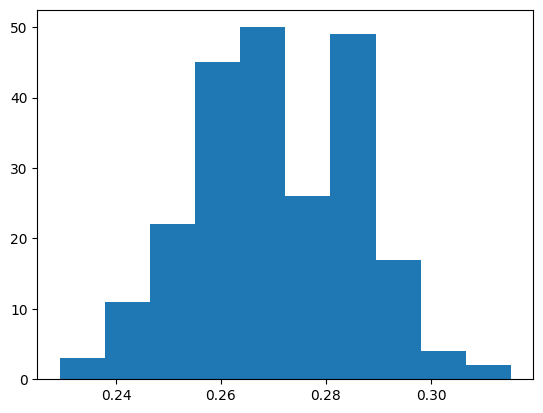

In [97]:
plt.hist(np.array(params_samples)[:,0])

(array([ 3., 18., 31., 54., 34., 32., 29., 12.,  9.,  7.]),
 array([-4859.65208583, -4818.76904628, -4777.88600674, -4737.00296719,
        -4696.11992765, -4655.2368881 , -4614.35384855, -4573.47080901,
        -4532.58776946, -4491.70472992, -4450.82169037]),
 <BarContainer object of 10 artists>)

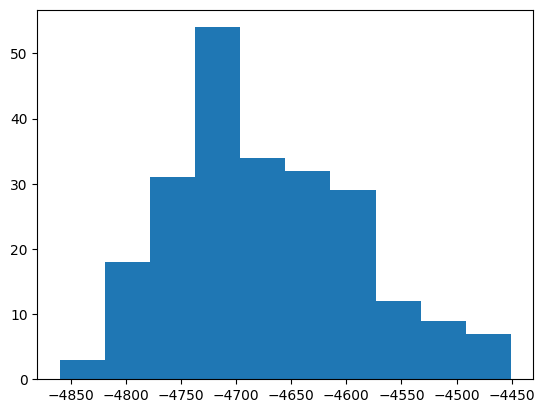

In [88]:
plt.hist(complete_likelihoods)

In [89]:
latenter_diff = []
for i in range(1, len(latent_samples)):
    latenter_diff.append(abs((latent_samples[i-1]-latent_samples[i])).sum().sum()/2)

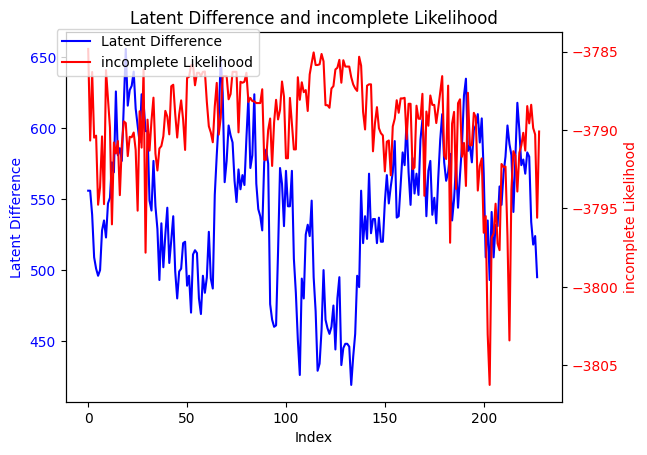

In [90]:
fig, ax1 = plt.subplots()

# Plot the first dataset (latenter_diff) on the primary y-axis
ax1.plot(latenter_diff, label='Latent Difference', color='blue')
ax1.set_xlabel('Index')
ax1.set_ylabel('Latent Difference', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create the secondary y-axis
ax2 = ax1.twinx()

# Plot the second dataset (incomplete_likelihoods) on the secondary y-axis
ax2.plot(incomplete_likelihoods, label='incomplete Likelihood', color='red')
ax2.set_ylabel('incomplete Likelihood', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Show the legend
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))

# Display the plot
plt.title("Latent Difference and incomplete Likelihood")
plt.show()

Text(0.5, 0, 'Iteration')

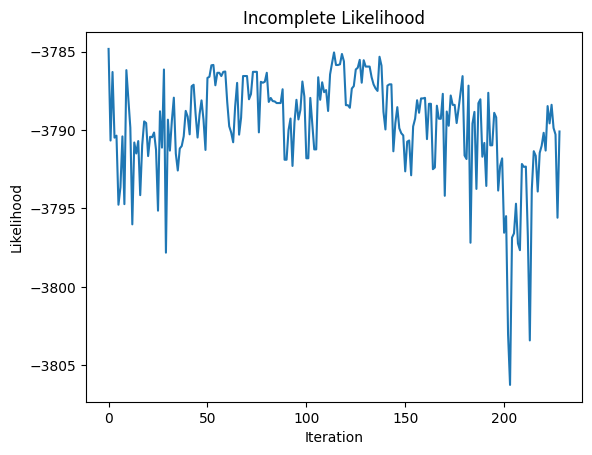

In [91]:
plt.plot(incomplete_likelihoods)
plt.title("Incomplete Likelihood")
plt.ylabel("Likelihood")
plt.xlabel("Iteration")



In [92]:
involvement_II = {'II': True}
involvement_III = {'III': True}
component_list = list(range(len(mixture.components)))
component_dictionary_early = {}


In [93]:
for component in component_list:
    risk_dictionary = {

        'II': [],
        'III': [],
    }
    for sample in params_samples:
        mixture.set_params(*sample)
        risk_dictionary['II'].append(mixture.components[component].risk(involvement = involvement_II, t_stage = 'early'))
        risk_dictionary['III'].append(mixture.components[component].risk(involvement = involvement_III, t_stage = 'early'))
    component_dictionary_early[str(component)] = risk_dictionary

In [94]:
from cycler import cycler
def multiple_plotter_component(risk_dictionary, component, stage = ''):
    COLORS = {
        "blue": '#005ea8',
        "orange": '#f17900',
        "red": '#ae0060',
    }
    hist_cycl = (
        cycler(histtype=["stepfilled", "step"])
        * cycler(color=list(COLORS.values()))
    )
    line_cycl = (
        cycler(linestyle=["-", "--"])
        * cycler(color=list(COLORS.values()))
    )
    min_value = 0
    max_value = 100
    prevalence = {}
    number_of_patients = {}
    risks = {}
    for key in risk_dictionary.keys():
        risks[key] = np.array(risk_dictionary[key])*100
    
    values = [risks[key] for key in risk_dictionary.keys()]
    hist_kwargs = {
                "bins": np.linspace(min_value, max_value, 80),
                "density": True,
                "alpha": 0.6,
                "linewidth": 2.,
            }
    fig, ax = plt.subplots(figsize=(12,4))

    x = np.linspace(min_value, max_value, 200)
    zipper = zip(values, risk_dictionary.keys(), hist_cycl)
    for vals, label, hstyle in zipper:
        ax.hist(
            vals,
            label=label,
            **hist_kwargs,
            **hstyle
        )
        ax.legend()
        ax.set_xlabel("probability [%]")
    plt.suptitle(f"Risk distributions {stage} for component {component}",fontsize = 16)
    

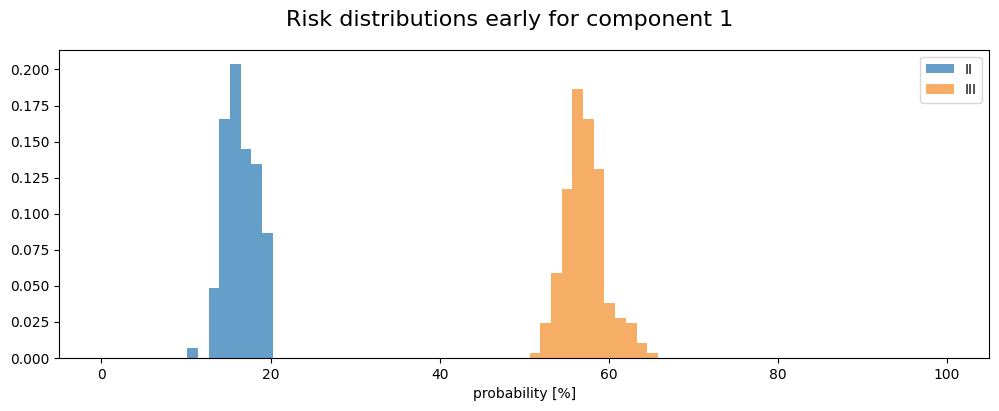

In [95]:
multiple_plotter_component(component_dictionary_early['1'], '1', 'early')

In [96]:
from cycler import cycler
import scipy as sp
def multiple_plotter(dataset, risk_dictionary, subsite, stage = ''):
    COLORS = {"green": '#00afa5',
        "blue": '#005ea8',
        "orange": '#f17900',
        "red": '#ae0060',
        "gray": '#c5d5db',
    }
    hist_cycl = (
        cycler(histtype=["stepfilled", "step"])
        * cycler(color=list(COLORS.values()))
    )
    line_cycl = (
        cycler(linestyle=["-", "--"])
        * cycler(color=list(COLORS.values()))
    )
    if stage == 'early' or stage == 'late':
        data_selected = dataset.loc[(dataset['tumor']['1']['subsite'] == subsite) & (dataset['tumor']['1']['t_stage'] == stage)]  
    else:
        data_selected = dataset.loc[dataset['tumor']['1']['subsite'] == subsite]
    min_value = 0
    max_value = 100
    prevalence = {}
    number_of_patients = {}
    risks = {}
    for key in risk_dictionary.keys():
        prevalence[key] = (data_selected['path']['ipsi'][key] == True).sum()
        number_of_patients[key] = len(data_selected)
        risks[key] = np.array(risk_dictionary[key])*100
    
    num_matches = [prevalence[key] for key in risk_dictionary.keys()]
    num_totals = [number_of_patients[key] for key in risk_dictionary.keys()]
    values = [risks[key] for key in risk_dictionary.keys()]
    hist_kwargs = {
                "bins": np.linspace(min_value, max_value, 80),
                "density": True,
                "alpha": 0.6,
                "linewidth": 2.,
            }
    fig, ax = plt.subplots(figsize=(12,4))

    x = np.linspace(min_value, max_value, 200)
    zipper = zip(values, risk_dictionary.keys(), num_matches, num_totals, hist_cycl, line_cycl)
    for vals, label, a, n, hstyle, lstyle in zipper:
        ax.hist(
            vals,
            label=label,
            **hist_kwargs,
            **hstyle
        )
        if not np.isnan(a):
            post = sp.stats.beta.pdf(x / 100., a+1, n-a+1) / 100.
            ax.plot(x, post, label=f"{int(a)}/{int(n)}", **lstyle)
        ax.legend()
        ax.set_xlabel("probability [%]")
    plt.suptitle(f"Risk distributions {stage} for subsite {subsite}",fontsize = 16)
    

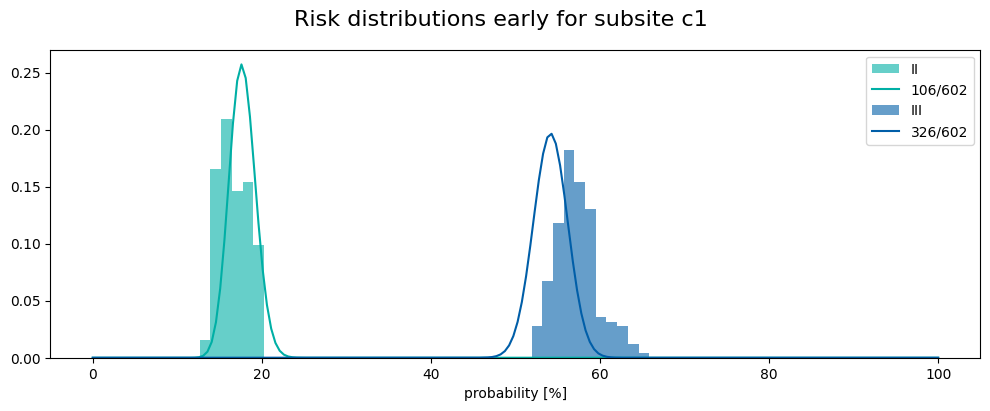

In [84]:
multiple_plotter(mixture.patient_data, component_dictionary_early['1'], 'c1', 'early')

## Old sampler

In [19]:
from lymixture.em import sample_model_params, get_complete_samples

samples = sample_model_params(mixture, steps = 20)
indices = np.random.choice(len(samples), 50, replace=False)
reduced_set = samples[indices]
complete_samples = get_complete_samples(mixture, reduced_set)

100%|██████████| 20/20 [00:04<00:00,  4.87it/s]


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
